# CSoT'26 - ML in Astronomy - Week 2 . Part 1: Baseline with Scikit-Learn (Starter)

**Goal:** Flatten the galaxy images into NumPy feature rows, train simple scikit-learn classifiers (KNN, Logistic Regression), and record the **baseline accuracy** that every later model must beat.

**Before you begin:**
1. Switch this notebook to a **GPU runtime** (`Runtime -> Change runtime type -> GPU`). The GPU isn't strictly needed for sklearn, but we reuse the Week 1 GPU pipeline.
2. Read [`01-tensors-to-numpy-and-flattening.md`](../01-tensors-to-numpy-and-flattening.md) and [`02-baseline-with-scikit-learn.md`](../02-baseline-with-scikit-learn.md).

Each `TODO` cell has a short instruction. Replace the placeholder with working code, then run the cell. **Do not** open the solution until you've genuinely attempted every TODO.

## Step 0 — Re-create the Week 1 data pipeline

Week 2 builds directly on the `DataLoader`s from Week 1. The cells below reproduce that pipeline (download is commented out — uncomment it the first time, exactly as in [`week1_data_solution.ipynb`](../../Week-1/notebooks/week1_data_solution.ipynb)). If you saved `galaxy_data/` to Google Drive in Week 1, just re-mount Drive and point `DATA_ROOT` at it instead of re-downloading.

After this section you should have `train_loader`, `val_loader`, `test_loader`, `train_ds`, and `num_classes`.

In [ ]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from torchvision.datasets import ImageFolder

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

Using: cuda


In [ ]:
# TODO: paste your Week 1 data pipeline here so that the following names are defined:
#   train_ds, val_ds, test_ds, train_loader, val_loader, test_loader, num_classes
#
# The quickest path is to copy the data-prep cells from
# ../../Week-1/notebooks/week1_data_solution.ipynb (Steps 1-8), then add:
#   num_classes = len(train_ds.classes)

from google.colab import userdata

os.environ['KAGGLE_USERNAME'] = userdata.get('username')
os.environ['KAGGLE_KEY'] = userdata.get('gal_morph')

RAW_ROOT = Path("galaxy_raw")      # <-- set up download here
IMAGES_DIR = RAW_ROOT / "images_gz2" /"images"  # flat image folder
DATA_ROOT = Path("galaxy_data")    # ImageFolder root (built in Step 3)

RAW_ROOT.mkdir(parents=True, exist_ok=True)

!kaggle datasets download -d jaimetrickz/galaxy-zoo-2-images -p {RAW_ROOT}
!unzip -q {RAW_ROOT}/galaxy-zoo-2-images.zip -d {RAW_ROOT}
print("Files extracted")

print("Downloading gz2_hart16.csv")
!wget -P {RAW_ROOT} https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz

print("Extracting labels file")
!gunzip -f {RAW_ROOT}/gz2_hart16.csv.gz

def high_level_label(gz2_class):
  if "E" in gz2_class:
    return "elliptical"
  elif "SB" in gz2_class:
    return "spiral_barred"
  elif "S" in gz2_class:
    return "spiral"
  else:
    return None

def build_imagefolder_layout(images_dir, mapping_csv,labels_csv, out_root, per_class=200, seed=42,
):
    mapping = pd.read_csv(mapping_csv)
    labels = pd.read_csv(labels_csv).rename(columns={"dr7objid": "objid"})
    df = mapping.merge(labels[["objid", "gz2_class"]], on="objid", how="inner")
    df["label"] = df["gz2_class"].map(high_level_label)
    df = df.dropna(subset=["label"])

    images_dir = Path(images_dir)
    out_root = Path(out_root)
    out_root.mkdir(parents=True, exist_ok=True)

    counts = {}
    for label in sorted(df["label"].unique()):
        class_dir = out_root / label
        class_dir.mkdir(exist_ok=True)
        rows = df[df["label"] == label]
        if len(rows) > per_class:
            rows = rows.sample(n=per_class, random_state=seed)
        linked = 0
        for _, row in rows.iterrows():
            src = images_dir / f"{int(row.asset_id)}.jpg"
            dst = class_dir / f"{int(row.asset_id)}.jpg"
            if src.exists() and not dst.exists():
                os.symlink(src.resolve(), dst)
                linked += 1
        counts[label] = linked
    return counts

PER_CLASS = 200
counts = build_imagefolder_layout(
    IMAGES_DIR,
    RAW_ROOT / "gz2_filename_mapping.csv",
    RAW_ROOT / "gz2_hart16.csv",
    DATA_ROOT,
    per_class=PER_CLASS,
)
print("Symlinked per class:", counts)
print("DATA_ROOT classes:", sorted(p.name for p in DATA_ROOT.iterdir() if p.is_dir()))

Dataset URL: https://www.kaggle.com/datasets/jaimetrickz/galaxy-zoo-2-images
License(s): Attribution 4.0 International (CC BY 4.0)
galaxy-zoo-2-images.zip: Skipping, found more recently modified local copy (use --force to force download)
replace galaxy_raw/gz2_filename_mapping.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: Files extracted
--2026-06-09 13:56:08--  https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz
Resolving gz2hart.s3.amazonaws.com (gz2hart.s3.amazonaws.com)... 16.15.183.113, 16.15.228.183, 52.216.27.76, ...
Connecting to gz2hart.s3.amazonaws.com (gz2hart.s3.amazonaws.com)|16.15.183.113|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 78513011 (75M) [application/x-gzip]
Saving to: ‘{RAW_ROOT_}/gz2_hart16.csv.gz’

gz2_hart16.csv.gz   100%[===================>]  74.88M  41.8MB/s    in 1.8s    

2026-06-09 13:56:10 (41.8 MB/s) - ‘{RAW_ROOT_}/gz2_hart16.csv.gz’ saved [78513011/78513011]

Extracting labels file


FileNotFoundError: [Errno 2] No such file or directory: 'galaxy_raw/gz2_hart16.csv'

In [ ]:
from torchvision import transforms
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5],
    ),
])

In [ ]:
dataset = ImageFolder(root=DATA_ROOT, transform=transform)
total_size = len(dataset)
train_size = int(0.70 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

generator = torch.Generator().manual_seed(42)
train_ds, val_ds, test_ds = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=generator
)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)

num_classes = len(train_ds.dataset.classes)

## Step 1 - From DataLoader to NumPy feature matrices

scikit-learn wants a 2D array `X` of shape `(n_samples, n_features)` and a 1D array `y` of labels. We get there by iterating the loader, flattening each batch with `flatten(start_dim=1)` (keeping the batch dim), and concatenating.

In [ ]:
# TODO: write loader_to_numpy(loader) that returns (X, y) as NumPy arrays.
#   - for each (images, labels) batch: flat = images.flatten(start_dim=1)
#   - collect flat.numpy() and labels.numpy(), then np.concatenate along axis 0
# Then build X_train, y_train from train_loader and X_test, y_test from test_loader.
# Print X_train.shape and X_test.shape (expect (N, 12288)).

def loader_to_numpy(loader):
  xs, ys = [], []
  for images, labels in loader:
    flat = images.flatten(start_dim=1)       # (B, 12288)
    xs.append(flat.numpy())
    ys.append(labels.numpy())
  X = np.concatenate(xs, axis=0)               # (N, 12288)
  y = np.concatenate(ys, axis=0)               # (N,)
  return X, y

X_train, y_train = loader_to_numpy(train_loader)
X_test, y_test = loader_to_numpy(test_loader)
print(X_train.shape)
print(X_test.shape)

(420, 12288)
(90, 12288)


## Step 2 - The 'do-nothing' floors

Before any real model: the majority-class baseline. A model that always predicts the most common class already scores this much - so this, not random chance, is the number to beat.

In [ ]:
# TODO: fit a DummyClassifier(strategy="most_frequent") on (X_train, y_train)
#       and print its accuracy on (X_test, y_test). Also print 1/num_classes (random).

from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent") # majority class
dummy.fit(X_train, y_train)
acc_major = dummy.score(X_test, y_test)
acc_random = 1/num_classes
print("Majority-class accuracy:", acc_major)
print("Random-selection accuracy: ", acc_random)

Majority-class accuracy: 0.3
Random-selection accuracy:  0.3333333333333333


## Step 3 - K-Nearest Neighbours

KNN classifies a galaxy by majority vote of its `k` closest training galaxies in 12 288-D pixel space. There is no real 'training' - it just memorises the data.

In [ ]:
# TODO: fit KNeighborsClassifier(n_neighbors=5) on the train set and print its TEST accuracy.

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
acc_knn = knn.score(X_test, y_test)
print(f"KNN accuracy: {acc_knn:.3f}")

KNN accuracy: 0.478


## Step 4 - Logistic Regression

A linear classifier: a weighted sum of the 12 288 pixel features per class, squashed by a softmax. Effectively a single-layer neural network. `max_iter` is raised because high-dimensional data is slow to converge.

In [ ]:
# TODO: fit LogisticRegression(max_iter=1000) on the train set and print its TEST accuracy.

from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
acc_regression = logreg.score(X_test, y_test)
print(f"Logistic Regression accuracy: {acc_regression:.3f}")

Logistic Regression accuracy: 0.478


## Step 5 - The comparison table (the bar to beat)

Put the numbers side by side. The best of these is the baseline your Week 3 CNN must clearly beat.

In [ ]:
# TODO: print a small table comparing: random (1/num_classes), majority, KNN, LogReg.
#       Identify (in a print statement) the single number Week 3 must beat.
print(f"{'Model':<25} | {'Test Accuracy':<15}")
print("-" * 43)
models = [
    ("Random Guess", acc_random),
    ("Majority Class", acc_major),
    ("K-Nearest Neighbors", acc_knn),
    ("Logistic Regression", acc_regression)
]
for name, acc in models:
    print(f"{name:<25} | {acc:.3%}")

print("-"*43)
best = max([acc_random, acc_major, acc_knn, acc_regression])
print("Best Score: ", best)

Model                     | Test Accuracy  
-------------------------------------------
Random Guess              | 33.333%
Majority Class            | 30.000%
K-Nearest Neighbors       | 47.778%
Logistic Regression       | 47.778%
-------------------------------------------
Best Score:  0.4777777777777778


## Step 6 (stretch) - Confusion matrix

Accuracy hides *which* classes get confused. Plot a confusion matrix for the logistic-regression predictions and note the most-confused pair - we'll compare it to the CNN's matrix in Week 3.

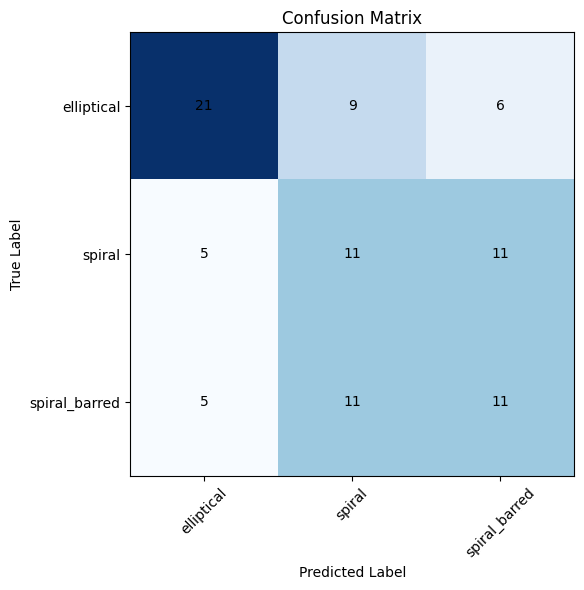

In [ ]:
# TODO (optional): plot a confusion matrix for KNN or LogReg predictions.
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
y_pred = logreg.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
class_names = train_ds.dataset.classes
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)

tick_marks = np.arange(len(class_names))
ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)
ax.set_xticklabels(class_names, rotation=45)
ax.set_yticklabels(class_names)

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),ha="center", va="center")

ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

## Reflection *(write 2-3 sentences each)*

1. What baseline accuracy did you reach, and how far above the majority-class floor is it?
2. Why does flattening hurt a *galaxy* classifier specifically? (Hint: isophote shape, arms - see [`03-surface-brightness-and-isophotes.md`](../03-surface-brightness-and-isophotes.md).)
3. Which two classes do you expect a CNN to still find hardest to separate, and why?

*1. 0.478(47.78%) which is 0.145 more than the majority-class floor.*<br>
*2. flattening breaks the spatial correlation so distinguishing spiral arms and concentric gradients is nearly impossible.*<br>
*3. elliptical and spiral, in edge on view.*<br>